In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

**charger les données**

In [2]:
iris = load_iris(as_frame=True)
X = iris.data            # 4 mesures : longueur/largeur des sépales et des pétales
y = iris.target          # 0 = setosa, 1 = versicolor, 2 = virginica
noms_classes = ["setosa", "versicolor", "virginica"]

print(X.shape[0], "fleurs,", X.shape[1], "mesures")
X.head()

150 fleurs, 4 mesures


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


**Séparation données**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42   # stratify : même proportion d'espèces partout
)
print(f"Entraînement : {len(X_train)}  |  Test : {len(X_test)}")

Entraînement : 105  |  Test : 45


**Softmax function**

In [4]:
modele_softmax = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000)),    # softmax automatique avec 3 classes
])
modele_softmax.fit(X_train, y_train)
y_pred_softmax = modele_softmax.predict(X_test)
print(f"Accuracy (softmax) : {accuracy_score(y_test, y_pred_softmax):.3f}")

Accuracy (softmax) : 0.911


**One-Vs-Rest**

In [5]:
modele_ovr = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", OneVsRestClassifier(LogisticRegression(max_iter=1000))),   # 3 modèles binaires
])
modele_ovr.fit(X_train, y_train)
y_pred_ovr = modele_ovr.predict(X_test)
print(f"Accuracy (One-vs-Rest) : {accuracy_score(y_test, y_pred_ovr):.3f}")

Accuracy (One-vs-Rest) : 0.844


**comparaison de deux méthodes**

In [6]:
fleur = X_test.iloc[[0]]
print(f"Vraie espèce : {noms_classes[y_test.iloc[0]]}\n")

proba_softmax = modele_softmax.predict_proba(fleur)[0]
proba_ovr = modele_ovr.predict_proba(fleur)[0]

pd.DataFrame({
    "classe": noms_classes,
    "softmax": proba_softmax.round(3),
    "One-vs-Rest": proba_ovr.round(3),
})

Vraie espèce : virginica



,classe,softmax,One-vs-Rest
0,setosa,0.000,0.000
1,versicolor,0.101,0.364
2,virginica,0.899,0.636


**vérification sans sklearn**

In [7]:
scores = modele_softmax.decision_function(fleur)[0]   # scores bruts z (un par classe)
print("Scores bruts z :", scores.round(2))

exp_z = np.exp(scores)
print("e^z            :", exp_z.round(2))

proba_main = exp_z / exp_z.sum()                      # formule du softmax
print("Softmax (main) :", proba_main.round(3))
print("scikit-learn   :", proba_softmax.round(3))     # identique !

Scores bruts z : [-6.08  1.95  4.13]
e^z            : [ 0.    7.04 62.35]
Softmax (main) : [0.    0.101 0.899]
scikit-learn   : [0.    0.101 0.899]


**voir les 3 modèles OvR séparément**

In [8]:
ovr = modele_ovr.named_steps["logreg"]
fleur_norm = modele_ovr.named_steps["scaler"].transform(fleur)

total = 0
for nom, clf in zip(noms_classes, ovr.estimators_):
    p = clf.predict_proba(fleur_norm)[0, 1]
    total += p
    print(f"Modèle « {nom} contre les autres » : {p:.3f}")
print(f"\nTotal = {total:.3f} → différent de 1, d'où la normalisation")

Modèle « setosa contre les autres » : 0.000
Modèle « versicolor contre les autres » : 0.524
Modèle « virginica contre les autres » : 0.915

Total = 1.439 → différent de 1, d'où la normalisation


**Métriques et matrice de confusion**

              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      0.824     0.933     0.875        15
   virginica      0.923     0.800     0.857        15

    accuracy                          0.911        45
   macro avg      0.916     0.911     0.911        45
weighted avg      0.916     0.911     0.911        45



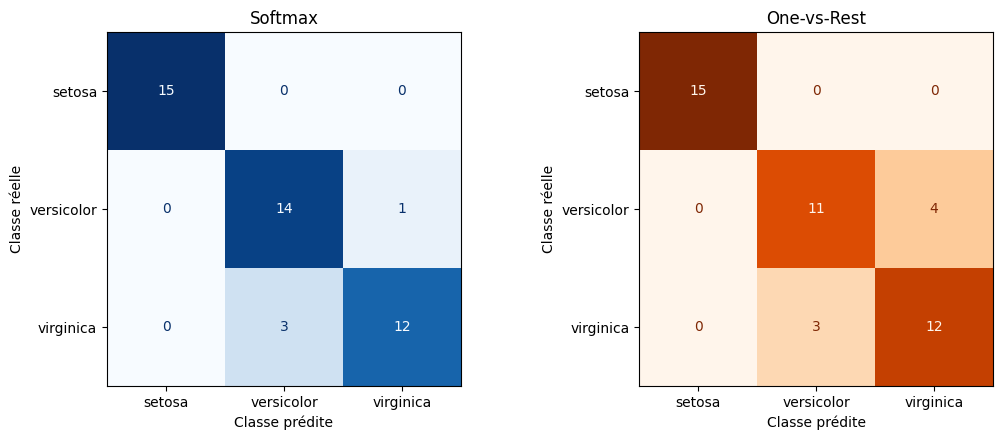

In [9]:
print(classification_report(y_test, y_pred_softmax, target_names=noms_classes, digits=3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_softmax, display_labels=noms_classes,
                                        cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Softmax")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ovr, display_labels=noms_classes,
                                        cmap="Oranges", ax=axes[1], colorbar=False)
axes[1].set_title("One-vs-Rest")
for ax in axes:
    ax.set_xlabel("Classe prédite")
    ax.set_ylabel("Classe réelle")
plt.tight_layout()
plt.show()

**Prédire une nouvelle fleur **

In [10]:
nouvelle = pd.DataFrame([{
    "sepal length (cm)": 6.0, "sepal width (cm)": 2.9,
    "petal length (cm)": 4.5, "petal width (cm)": 1.5,
}])
p = modele_softmax.predict_proba(nouvelle)[0]
for nom, val in zip(noms_classes, p):
    print(f"{nom:<11} : {val * 100:5.1f} %")
print(f"\nEspèce prédite : {noms_classes[p.argmax()]}")

setosa      :   1.7 %
versicolor  :  75.7 %
virginica   :  22.5 %

Espèce prédite : versicolor


###   Test

In [11]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Définition des widgets curseurs (sliders) basés sur les valeurs min/max du dataset Iris
sepal_length_slider = widgets.FloatSlider(value=6.0, min=4.0, max=8.0, step=0.1, description='Long. sépale (cm)', style={'description_width': 'initial'})
sepal_width_slider = widgets.FloatSlider(value=3.0, min=2.0, max=4.5, step=0.1, description='Larg. sépale (cm)', style={'description_width': 'initial'})
petal_length_slider = widgets.FloatSlider(value=4.0, min=1.0, max=7.0, step=0.1, description='Long. pétale (cm)', style={'description_width': 'initial'})
petal_width_slider = widgets.FloatSlider(value=1.3, min=0.1, max=2.5, step=0.1, description='Larg. pétale (cm)', style={'description_width': 'initial'})

# Zone d'affichage des résultats
output = widgets.Output()

def predire_et_afficher(change=None):
    with output:
        clear_output(wait=True)

        # 1. Récupération des données saisies
        saisie = pd.DataFrame([{
            "sepal length (cm)": sepal_length_slider.value,
            "sepal width (cm)": sepal_width_slider.value,
            "petal length (cm)": petal_length_slider.value,
            "petal width (cm)": petal_width_slider.value,
        }])

        # 2. Prédictions
        p_softmax = modele_softmax.predict_proba(saisie)[0]
        classe_predite = noms_classes[p_softmax.argmax()]

        # 3. Affichage visuel des probabilités
        print(f"🔮 ESPÈCE PRÉDITE : {classe_predite.upper()}\n")
        for nom, val in zip(noms_classes, p_softmax):
            barre = "█" * int(val * 20)
            print(f"{nom:<11} : [{barre:<20}] {val * 100:5.1f} %")

# Lier les changements de curseurs à la fonction de prédiction
for slider in [sepal_length_slider, sepal_width_slider, petal_length_slider, petal_width_slider]:
    slider.observe(predire_et_afficher, names='value')

# Organisation de l'interface
interface = widgets.VBox([
    widgets.HTML("<h4>Ajustez les dimensions de la fleur :</h4>"),
    sepal_length_slider,
    sepal_width_slider,
    petal_length_slider,
    petal_width_slider,
    widgets.HTML("<hr>"),
    output
])

# Affichage initial de l'application
display(interface)
predire_et_afficher()